# 03 · Energy production growth in California (supply side of RQ2)

Chapter 3 of *Mapping the Consumption Gap*. Generation and imports since 2010, capacity, batteries and curtailment, the retirement schedule, a supply-side realization model estimated on EIA-860M vintages, and probability-weighted planned supply for 2030 in three cases.

Outputs are produced by `scripts/run_chapter3.py` from `src/ch3_supply.py` (about six minutes: sixteen EIA-923 and sixteen EIA-860 annual files plus eighteen EIA-860M monthly files are parsed from the raw zips and workbooks); this notebook displays them.

| Step | Sources (manifest ids) |
|---|---|
| 1. Generation, imports, capacity, storage, curtailment | `eia923_2010..2025`, `eia860_2010..2025`, `cec_elec_energy_generation_page`, `cec_2015..2024_total_system_electric_generation`, `cec_gen_capacity_energy_page`, `caiso_curtailments_monthly_csv` |
| 2. Retirements | `eia860m_2026_07`, `swrcb_otc_policy_2023` |
| 3. Realization model | `eia860m_2016_01 .. 2022_01` (vintages), `eia860m_2016_12 .. 2025_12` (outcomes and exit timing) |
| 4. 2030 cases | `eia860m_2026_07` (current planned list), `eia860m_2025_12` (existing), `cpuc_e3_astrape_incremental_elcc_2023` (ELCC), chapter 1 tables |


In [1]:
import sys, json, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent))
import pandas as pd, numpy as np
from IPython.display import Image, display
from src.paths import PROCESSED, FIGURES
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 80)
def show(name): display(Image(filename=str(FIGURES / f"{name}.png")))
def table(name, **kw): return pd.read_csv(PROCESSED / f"{name}.csv", **kw)

## 1. Generation by resource, imports, capacity, batteries, curtailment

In-state generation by resource is built from the EIA-923 Page 1 schedule (California plants, reported fuel and prime mover classified into resource classes; hydro is not split by size because EIA-923 carries no unit capacity). Net imports are the CEC's statewide total-system series (2012-2024; the CEC has not yet published 2025 imports, and the 2021 per-year page on the CEC site repeats the 2020 table, so the multi-year table is used). The CAISO-only net interchange from chapter 1 is shown as a proxy for 2019-2025.

In [2]:
s = table("ch3_supply_by_year", index_col=0); (s / 1000).round(1).loc[[2010, 2012, 2015, 2018, 2020, 2022, 2023, 2024, 2025]]

,Batteries,Biomass,Coal and petcoke,Geothermal,Hydro,Natural gas,Nuclear,Oil,Other,Pumped storage,Solar,Total in-state,Wind,CEC net imports,"CAISO net imports (EIA-930, chapter 1)"
year,,,,,,,,,,,,,,,
2010,0.0,6.2,3.1,12.6,33.4,109.2,32.2,0.1,0.7,-0.2,0.8,204.1,6.1,NaN,NaN
2012,0.0,6.5,1.5,12.5,26.8,121.2,18.5,0.1,0.7,0.6,1.4,199.5,9.8,102.5,NaN
2015,-0.0,6.7,0.3,11.9,13.8,117.7,18.5,0.1,0.6,0.1,14.8,196.7,12.2,99.0,NaN
2018,-0.0,6.1,0.3,11.7,26.3,91.3,18.2,0.0,0.7,-0.1,27.0,195.5,14.0,90.6,NaN
2020,-0.0,5.8,0.3,11.4,21.4,93.6,16.3,0.0,0.6,-0.0,30.3,193.1,13.6,81.9,59.4
2022,-0.4,5.6,0.3,11.2,17.6,97.8,17.6,0.1,0.5,-0.2,38.8,203.4,14.6,84.2,48.7
2023,-0.9,5.2,0.2,11.3,32.4,95.8,17.7,0.0,0.3,-0.4,41.0,216.6,14.0,65.5,28.8
2024,-1.4,4.8,0.2,10.5,29.5,87.9,18.4,0.0,0.2,-0.0,48.4,214.2,15.6,62.2,31.7
2025,-1.9,4.3,0.2,10.9,28.1,75.4,17.6,0.0,0.3,0.2,54.9,205.1,15.1,NaN,36.1


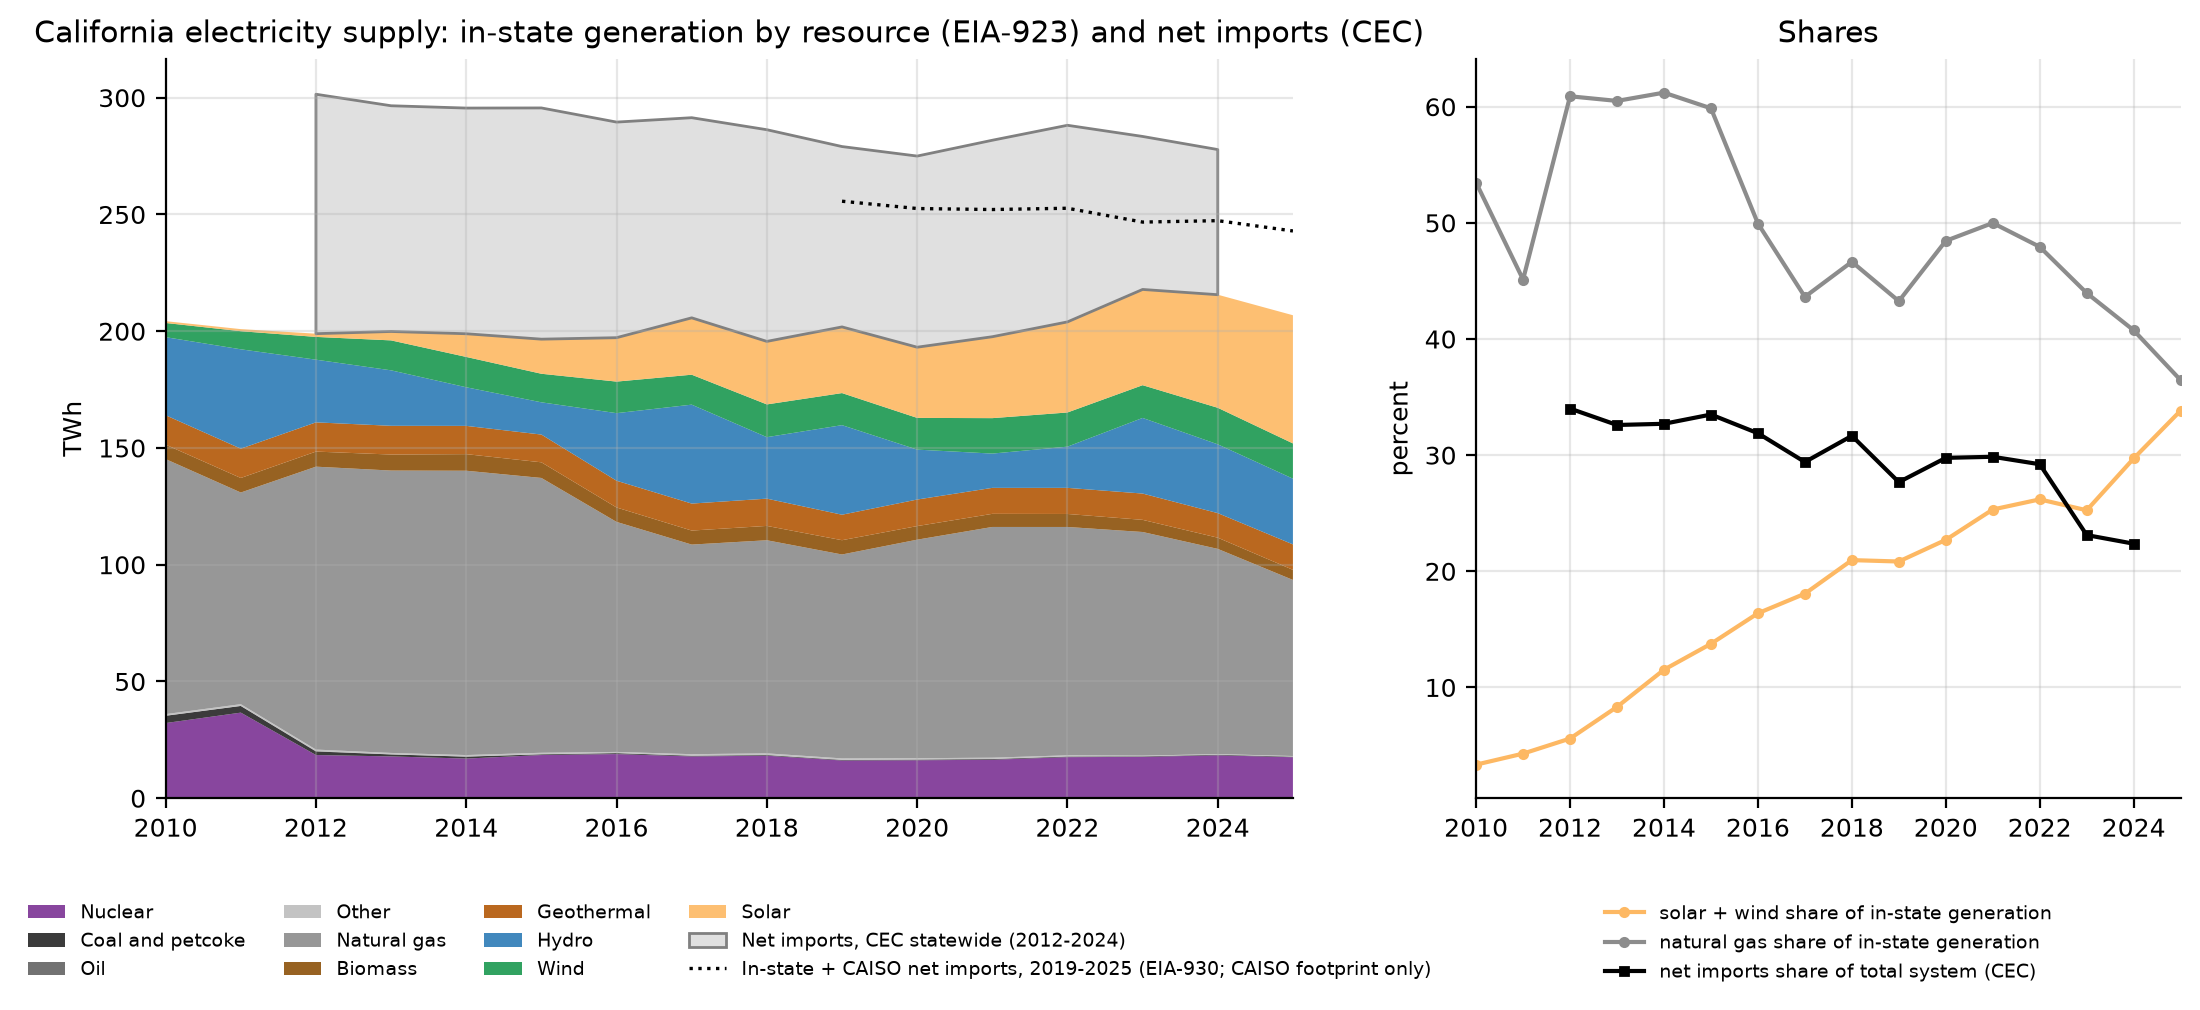

In [3]:
show("fig3_01_generation_by_resource")

In [4]:
table("ch3_cec_imports_by_year").round(0)

,year,in_state_gwh,nw_imports_gwh,sw_imports_gwh,energy_mix_gwh,multi_year_in_state_gwh,consistent,note
0,2015,196195.0,35800.0,63410.0,295405,196859.0,True,NaN
1,2016,198227.0,42378.0,49963.0,290567,198471.0,True,NaN
2,2017,206336.0,39873.0,45830.0,292039,206411.0,True,NaN
3,2018,194842.0,39517.0,51130.0,285488,195234.0,True,NaN
4,2019,200475.0,23930.0,53299.0,277704,200945.0,True,NaN
5,2020,194127.0,32572.0,51064.0,277764,192332.0,True,NaN
6,2021,194127.0,32572.0,51064.0,277764,196605.0,False,page repeats the previous year's table; dropped
7,2022,203257.0,34180.0,49782.0,287220,202357.0,True,NaN
8,2023,215623.0,15925.0,49593.0,281140,215623.0,True,NaN
9,2024,216181.0,15813.0,46344.0,278338,216181.0,True,NaN


In [5]:
c = table("ch3_eia860_capacity_by_resource"); (c.pivot(index="year", columns="resource", values="nameplate_mw") / 1000).round(1).loc[[2010, 2013, 2016, 2019, 2022, 2025]]

resource,Batteries,Biomass,Coal and petcoke,Geothermal,Large hydro,Natural gas,Nuclear,Oil,Other,Pumped storage,Small hydro,Solar,Total,Wind
year,,,,,,,,,,,,,,
2010,NaN,1.2,0.6,2.9,7.9,45.5,4.6,0.7,0.4,3.4,2.1,0.5,72.6,2.8
2013,0.0,1.5,0.3,3.0,7.9,48.3,2.3,0.6,0.2,3.8,2.1,3.4,79.0,5.6
2016,0.1,1.5,0.1,2.9,7.9,45.2,2.3,0.5,0.1,3.7,2.1,9.9,82.1,5.7
2019,0.3,1.4,0.1,2.8,7.9,40.5,2.3,0.6,0.1,3.7,2.1,12.8,80.8,6.2
2022,4.9,1.3,0.1,2.9,7.9,41.4,2.3,0.5,0.1,3.7,2.1,17.7,91.1,6.2
2025,14.9,1.1,0.1,2.9,8.0,40.4,2.3,0.6,0.1,3.7,2.0,24.8,107.4,6.5


In [6]:
pd.concat([table("ch3_battery_capacity").set_index("year"), table("ch3_caiso_curtailment_annual").set_index("year")], axis=1).round(0)

,units,power_mw,energy_mwh,curtailed_gwh,months
year,,,,,
2016,21.0,120.0,242.0,308.0,12
2017,26.0,162.0,414.0,401.0,12
2018,34.0,234.0,534.0,461.0,12
2019,47.0,254.0,650.0,961.0,12
2020,59.0,535.0,919.0,1587.0,12
2021,92.0,2339.0,6406.0,1505.0,12
2022,130.0,4876.0,16658.0,2449.0,12
2023,165.0,8011.0,26743.0,2660.0,12
2024,227.0,11769.0,40223.0,3423.0,12


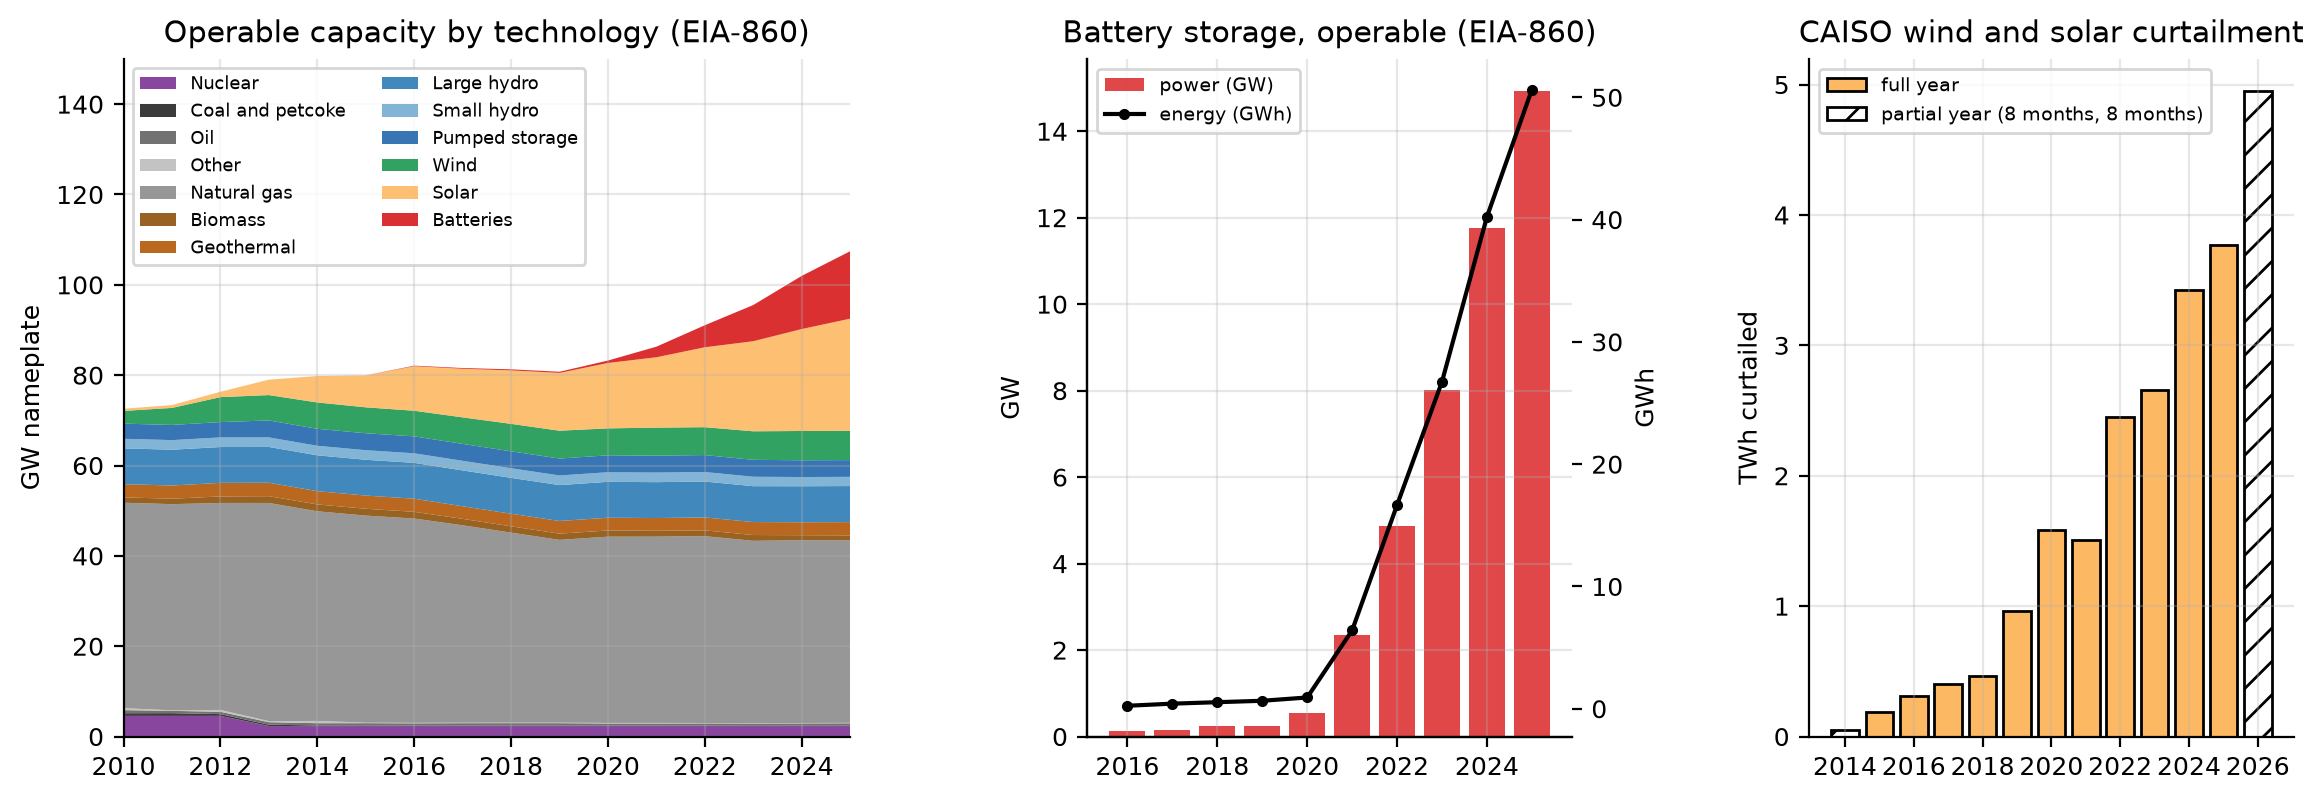

In [7]:
show("fig3_02_capacity_storage_curtailment")

**Reading.** In-state generation was 204 TWh in 2010 and 205 TWh in 2025, but its composition inverted: natural gas fell from 109 to 75 TWh (53 to 36 percent of in-state generation) and solar rose from under 1 to 55 TWh, so solar and wind together went from 3 to 34 percent. Nuclear halved with the San Onofre closure. Statewide net imports fell from 103 TWh in 2012 (34 percent of the total system) to 62 TWh in 2024 (22 percent). Operable capacity rose from 73 to 107 GW, of which solar added 24 GW and batteries 15 GW (51 GWh of energy capacity across 281 units by 2025); gas capacity fell only from 45 to 40 GW. Curtailment of wind and solar rose from 0.2 TWh in 2015 to 3.8 TWh in 2025, and reached 4.9 TWh in the first eight months of 2026.

## 2. Retirement schedule

EIA-860M planned retirement dates for every California operating unit, plus the State Water Board once-through-cooling compliance dates (Table 1 of the policy as amended August 2023): Alamitos 3-5, Huntington Beach 2 and Ormond Beach 1-2 by December 31, 2026; Haynes 1, 2 and 8, Harbor 5 and Scattergood 1-2 by December 31, 2029; Diablo Canyon 1-2 by October 31, 2030 (SB 846). Haynes, Harbor and Diablo Canyon carry no retirement date in EIA-860M; the OTC date is used for them in case C.

In [8]:
otc = table("ch3_otc_units"); otc[["plant_name", "gen_id", "technology", "mw", "operating_year", "eia_planned_retirement_year", "otc_compliance_date", "schedule_year"]]

,plant_name,gen_id,technology,mw,operating_year,eia_planned_retirement_year,otc_compliance_date,schedule_year
0,AES Alamitos LLC,3,Natural Gas Steam Turbine,310.0,1961.0,2026.0,2026-12-31,2026
1,AES Alamitos LLC,4,Natural Gas Steam Turbine,310.0,1962.0,2026.0,2026-12-31,2026
2,AES Alamitos LLC,5,Natural Gas Steam Turbine,495.0,1964.0,2026.0,2026-12-31,2026
3,AES Huntington Beach LLC,2,Natural Gas Steam Turbine,218.0,1958.0,2026.0,2026-12-31,2026
4,Ormond Beach,1,Natural Gas Steam Turbine,806.0,1971.0,2027.0,2026-12-31,2026
5,Ormond Beach,2,Natural Gas Steam Turbine,806.0,1973.0,2027.0,2026-12-31,2026
6,Haynes,1,Natural Gas Steam Turbine,230.0,1962.0,NaN,2029-12-31,2029
7,Haynes,2,Natural Gas Steam Turbine,230.0,1963.0,NaN,2029-12-31,2029
8,Haynes,8,Natural Gas Fired Combined Cycle,264.3,2005.0,NaN,2029-12-31,2029
9,Harbor,5,Natural Gas Fired Combined Cycle,75.0,1995.0,NaN,2029-12-31,2029


In [9]:
sched = table("ch3_eia860m_planned_retirements"); sched[sched.planned_retirement_year <= 2035].groupby(["planned_retirement_year", "resource"]).mw.sum().unstack().fillna(0).round(0)

resource,Biomass,Natural gas,Oil,Solar,Wind
planned_retirement_year,,,,,
2026.0,0.0,1333.0,0.0,0.0,0.0
2027.0,0.0,1612.0,0.0,0.0,0.0
2028.0,3.0,0.0,2.0,0.0,0.0
2029.0,0.0,408.0,0.0,0.0,0.0
2030.0,0.0,6.0,0.0,0.0,0.0
2031.0,0.0,1.0,0.0,0.0,87.0
2035.0,0.0,0.0,0.0,1.0,0.0


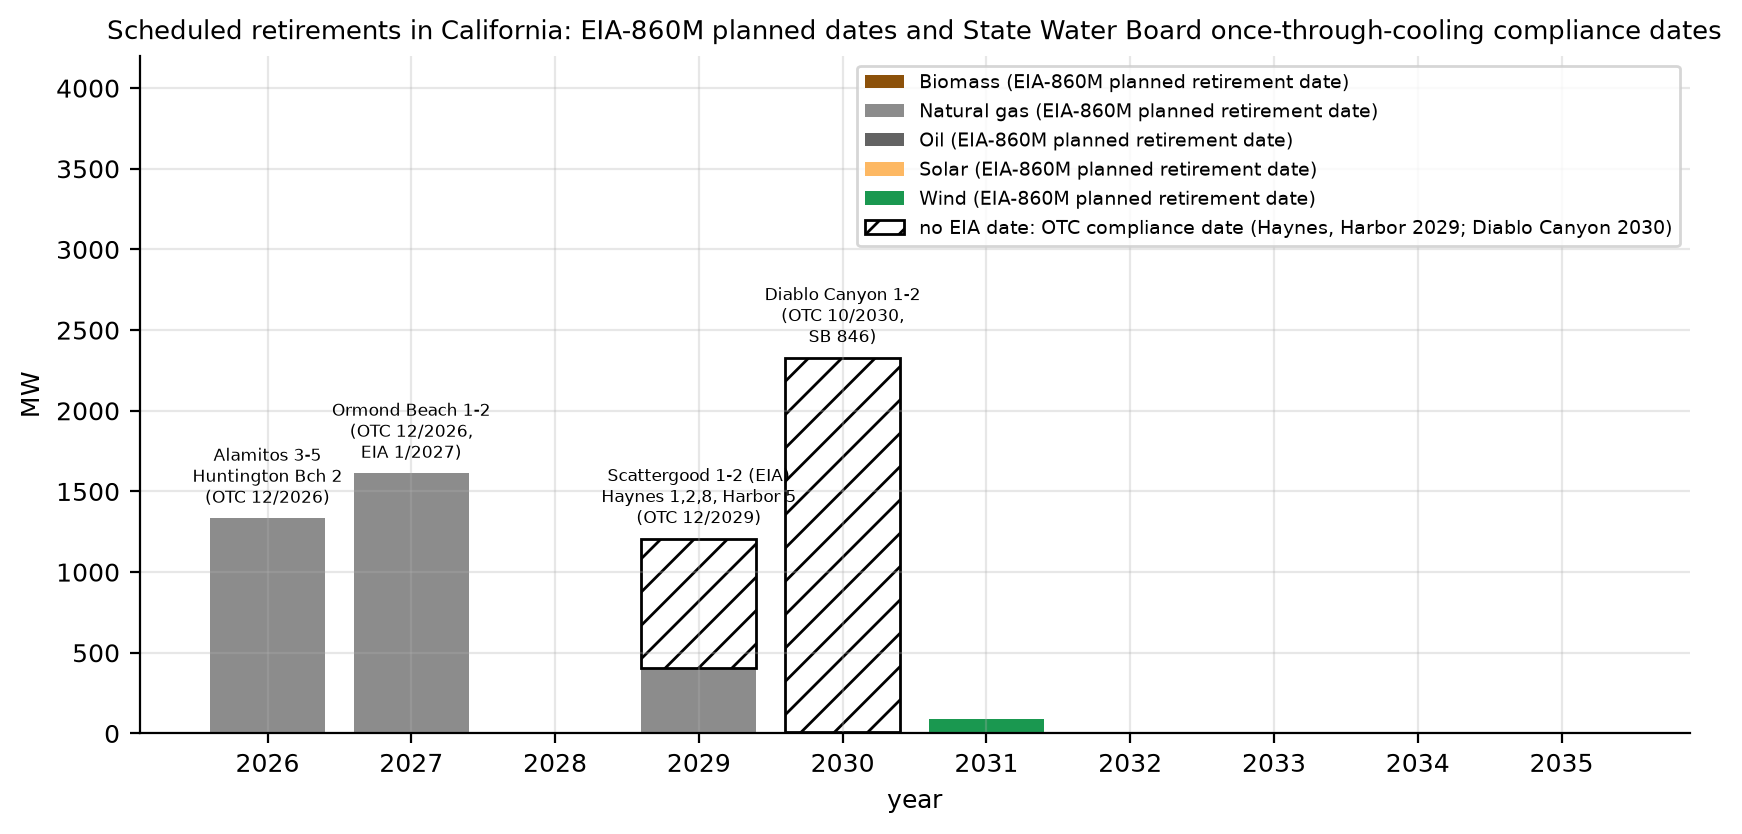

In [10]:
show("fig3_03_retirement_schedule")

## 3. Supply-side realization model

For every California unit in the Planned sheet of the January EIA-860M file of each year 2016-2022, the outcome by the December 2025 file is recorded: operating (or operated and since retired), cancelled (the cumulative Canceled or Postponed sheet), still planned, or dropped from the survey without a cancellation record (treated as cancelled). Units that appear in several January lists contribute one observation per vintage; standard errors are clustered by unit.

- **Logistic model** of completion by December 2025 on technology, log nameplate, planned lead time (planned commercial date minus file date), the observation window (December 2025 minus file date) and construction status at the vintage.
- **Delay**: Kaplan-Meier time from the planned to the actual commercial date with cancellations censored (an upper bound), and the cumulative incidence of completion with cancellation as a competing risk (Aalen-Johansen).

In [11]:
table("ch3_realization_by_vintage").round(2)

,vintage,units,mw_planned,completed_units,completed_mw,cancelled_mw,still_planned_mw,completion_rate_units,completion_rate_mw,median_delay_months_completed
0,2016,145,8453.9,111,5591.7,2842.2,20.0,0.77,0.66,1.97
1,2017,110,6837.1,73,3475.2,3291.9,70.0,0.66,0.51,1.02
2,2018,110,8208.7,67,4138.0,3800.7,270.0,0.61,0.50,2.00
3,2019,115,7659.9,70,5245.2,2144.7,270.0,0.61,0.68,3.01
4,2020,127,7568.8,92,5768.1,1245.2,555.5,0.72,0.76,5.98
5,2021,150,10860.3,111,7661.1,371.7,2827.5,0.74,0.71,4.04
6,2022,168,14466.2,116,9801.6,518.8,4145.8,0.69,0.68,4.01


In [12]:
table("ch3_realization_by_technology").sort_values("mw_planned", ascending=False).round(2)

,resource,units,mw_planned,completed_units,completed_mw,cancelled_mw,still_planned_mw,completion_rate_units,completion_rate_mw,median_delay_months_completed
7,Solar,469,34524.2,338,24516.1,5129.6,4878.5,0.72,0.71,2.97
3,Natural gas,94,13164.0,57,5785.1,7378.9,0.0,0.61,0.44,0.99
0,Batteries,195,12434.0,142,9413.4,343.0,2677.6,0.73,0.76,4.01
8,Wind,53,2203.9,37,1711.3,195.1,297.5,0.70,0.78,5.03
2,Geothermal,23,1158.3,3,75.0,1083.3,0.0,0.13,0.06,6.96
5,Other,9,360.3,0,0.0,60.3,300.0,0.00,0.00,NaN
1,Biomass,61,164.1,49,143.7,15.2,5.2,0.80,0.88,1.97
6,Small hydro,20,45.1,13,35.3,9.8,0.0,0.65,0.78,28.06
4,Oil,1,1.0,1,1.0,0.0,0.0,1.00,1.00,2.99


In [13]:
table("ch3_realization_by_status").round(2)

,status_group,units,mw_planned,completed_units,completed_mw,cancelled_mw,still_planned_mw,completion_rate_units,completion_rate_mw,median_delay_months_completed
0,approvals not initiated,202,16684.9,112,8966.2,2311.6,5407.1,0.55,0.54,15.00
1,approvals pending,172,14869.2,109,8729.1,5213.5,926.6,0.63,0.59,6.96
2,"approved, not started",150,10582.2,80,6966.6,1798.2,1817.4,0.53,0.66,4.96
3,construction complete,72,1382.9,58,1272.3,108.0,2.6,0.81,0.92,0.00
4,under construction,329,20535.7,281,15746.7,4783.9,5.1,0.85,0.77,2.00


In [14]:
table("ch3_logit_coefficients").round(3)

,term,coef,se,p,odds_ratio
0,Intercept,0.290,0.554,0.601,1.336
1,"C(tech, Treatment('Solar'))[T.Batteries]",0.116,0.348,0.739,1.123
2,"C(tech, Treatment('Solar'))[T.Biomass]",-0.172,0.654,0.793,0.842
3,"C(tech, Treatment('Solar'))[T.Geothermal]",-2.180,1.122,0.052,0.113
4,"C(tech, Treatment('Solar'))[T.Natural gas]",-0.830,0.466,0.075,0.436
5,"C(tech, Treatment('Solar'))[T.Other]",-2.489,1.169,0.033,0.083
6,"C(tech, Treatment('Solar'))[T.Small hydro]",-0.034,0.961,0.972,0.967
7,"C(tech, Treatment('Solar'))[T.Wind]",-0.094,0.899,0.917,0.911
8,"C(status_group, Treatment('approvals not initiated'))[T.approvals pending]",0.087,0.416,0.834,1.091
9,"C(status_group, Treatment('approvals not initiated'))[T.approved, not started]",-0.273,0.344,0.429,0.761


In [15]:
summ = json.loads((PROCESSED / "ch3_logit_summary.json").read_text()); {k: v for k, v in summ.items() if k != "no_status"}

{'n_obs': 925,
 'n_units': 513,
 'pseudo_r2': 0.17806233562984664,
 'auc_in_sample': 0.7775877192982455,
 'llf': -469.54024001387086,
 'completion_rate_overall_units': 0.6918918918918919,
 'completion_rate_overall_mw': 0.6507058788632876,
 'delay': {'n_completed': 640,
  'median_delay_months': 2.9894875164257555,
  'mean_delay_months': 7.4342456471747695,
  'share_on_time_or_early': 0.2640625,
  'share_late_over_12m': 0.2375,
  'p90_delay_months': 24.014454664914584,
  'km_median_months_to_operation': 7.030223390275952,
  'cif_complete_36m': 0.6755367642286133,
  'cif_complete_60m': 0.705361499430717,
  'cif_cancel_60m': 0.23209868320643134}}

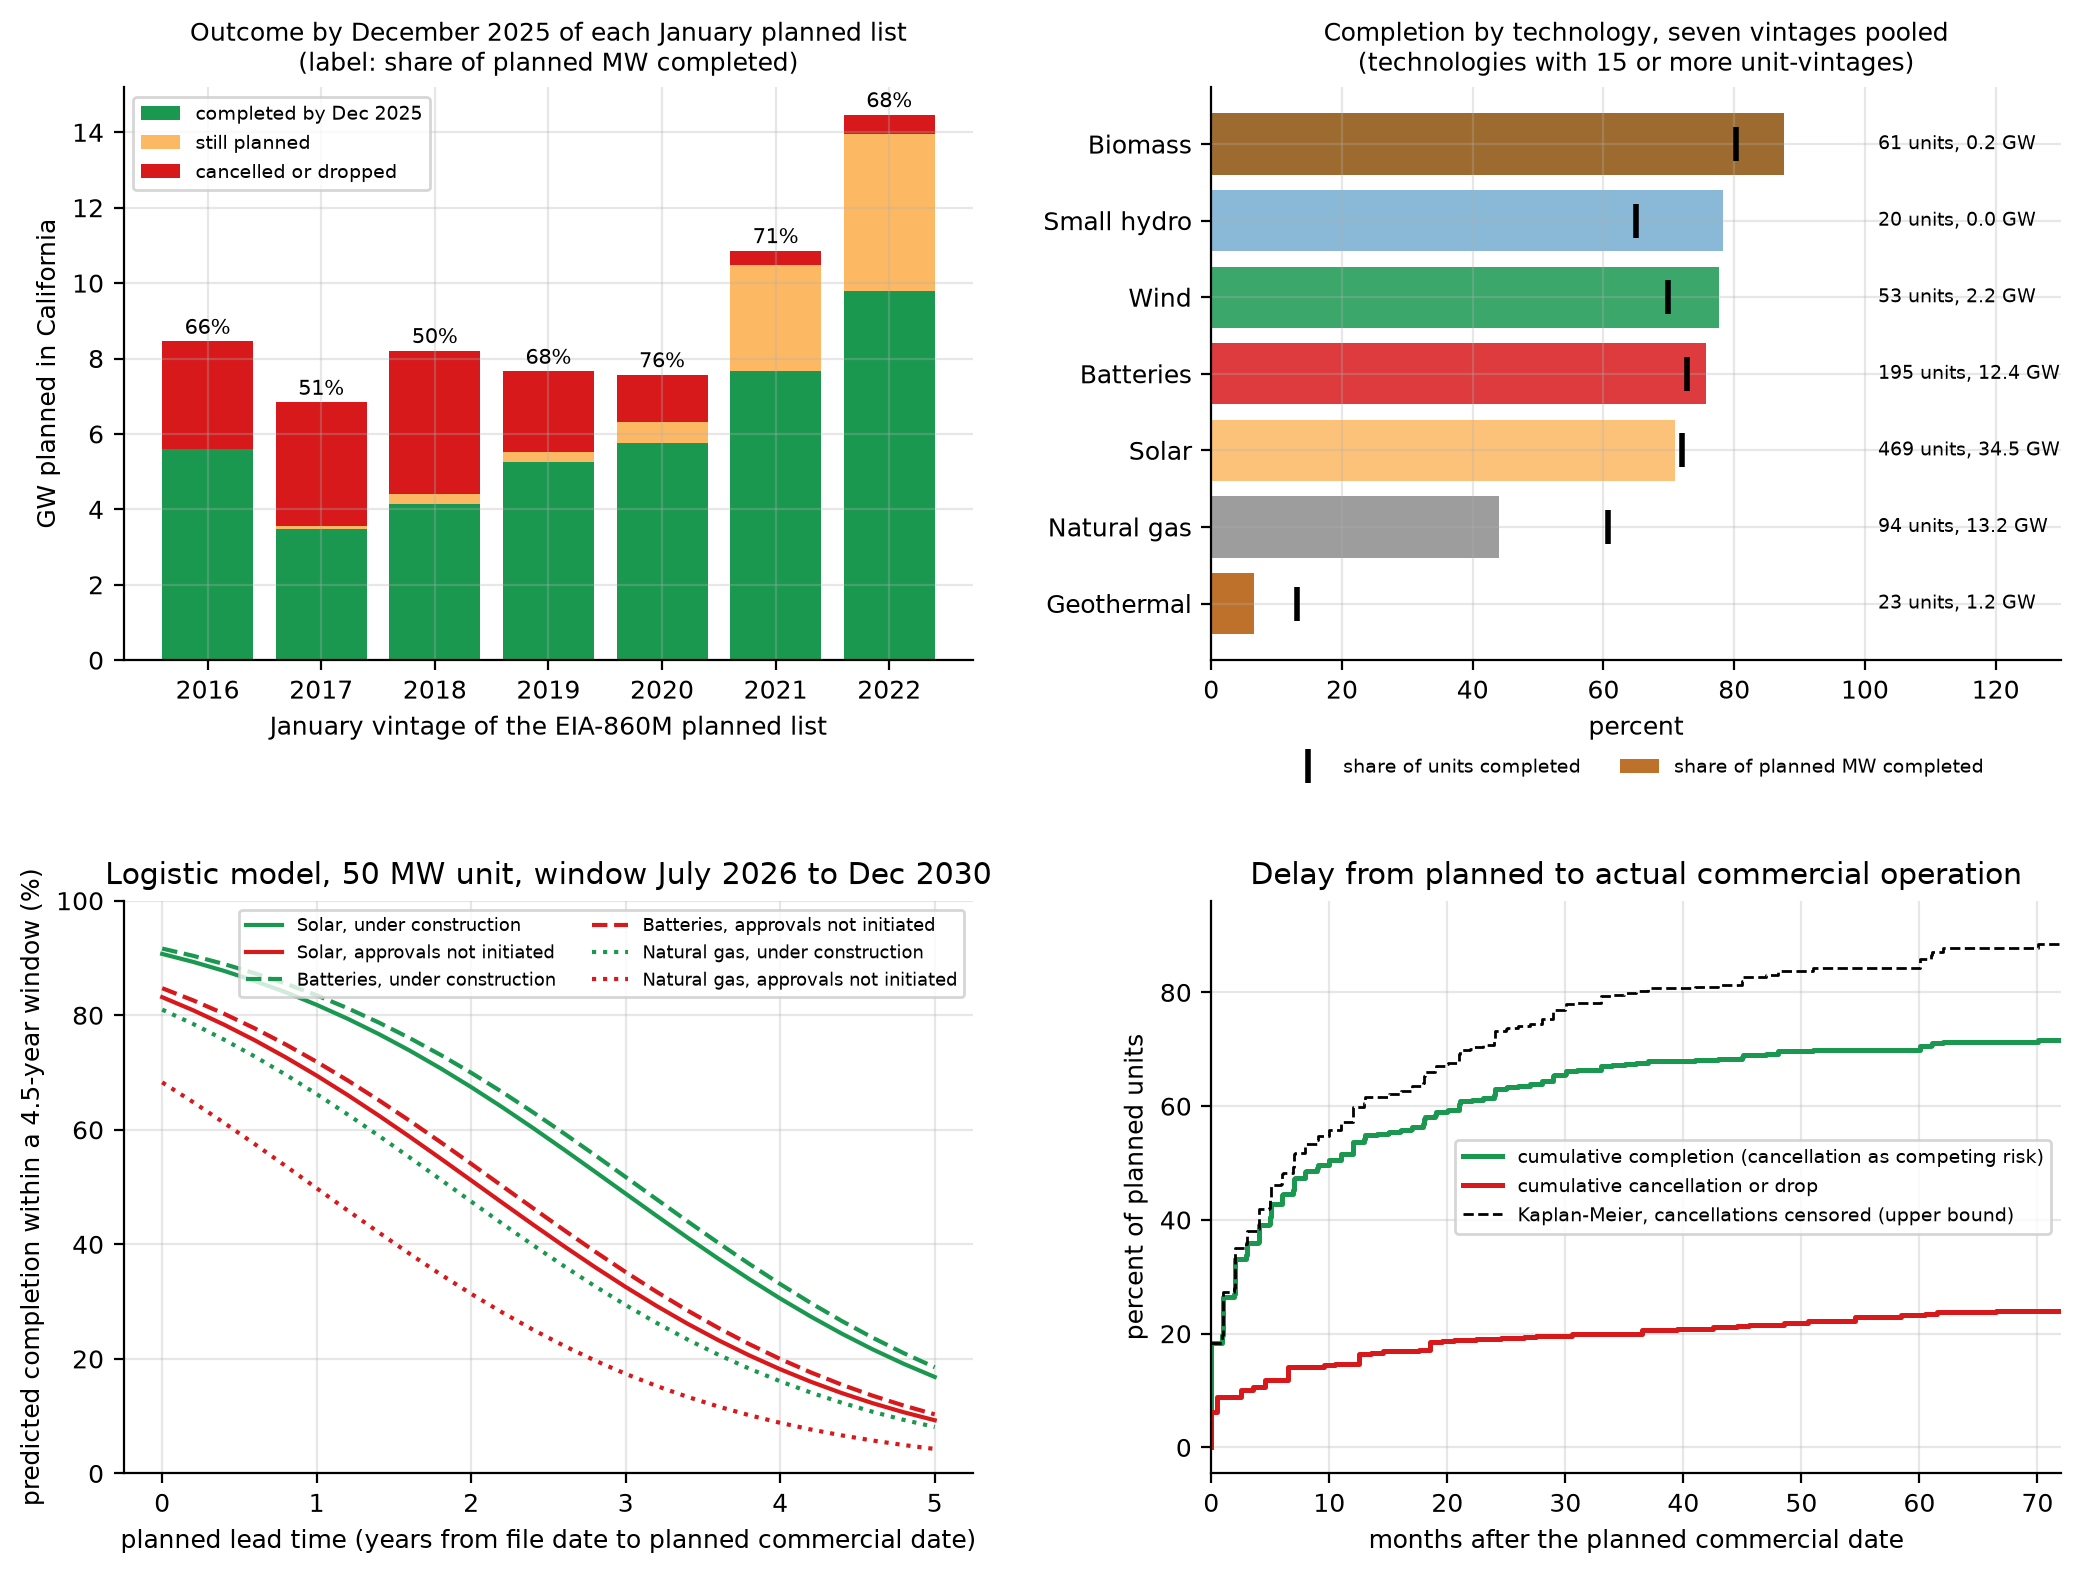

In [16]:
show("fig3_04_realization_model")

**Reading.** Across the seven January vintages (925 unit-vintages, 513 distinct units, 64 GW planned), 69 percent of units and 65 percent of planned megawatts were operating by December 2025; by vintage the megawatt completion rate ranges from 50 percent (2018) to 76 percent (2020). Solar (71 percent of MW), batteries (76) and wind (78) complete at similar rates; natural gas completes 44 percent of planned megawatts and geothermal 6 percent. Construction status is the strongest signal: units under construction at the vintage completed 77 percent of their megawatts against 54 percent for units whose approvals had not been initiated. In the logistic model each additional year of planned lead time cuts the odds of completion within the window by more than half (odds ratio 0.46), a longer observation window raises them (1.17 per year), being under construction doubles them (1.98), and gas and geothermal carry lower odds than solar. Among completed units the median delay from the planned to the actual commercial date is 3 months, a quarter are on time or early and a quarter are more than a year late; treating cancellation as a competing risk, 53 percent of planned units are operating within 12 months of their planned date, 62 percent within 24 and 70 percent within 60, while 23 percent have been cancelled or dropped by then.

## 4. Probability-weighted planned supply for 2030

The July 2026 planned list for California (229 units, 20.1 GW with planned dates through 2030) is weighted by the logistic model's completion probability for a window ending December 2030. Energy uses realised 2023-2025 capacity factors (batteries and pumped storage contribute no net energy); peak contribution uses ELCC values from the CPUC/E3-Astrape mid-term reliability study (2028 tranche) for solar, wind, batteries and pumped storage, and stated derates for firm resources and hydro. Case C subtracts the EIA planned retirements through 2030, the OTC units without an EIA date and Diablo Canyon at its OTC compliance date; a sensitivity keeps Diablo Canyon.

In [17]:
pl = table("ch3_planned_current_weighted"); pl[pl.planned_year <= 2030].groupby("resource").agg(units=("mw", "size"), planned_mw=("mw", "sum"), weighted_mw=("weighted_mw", "sum"), mean_p=("p_2030", "mean")).round(2)

,units,planned_mw,weighted_mw,mean_p
resource,,,,
Batteries,92,9921.8,7009.60,0.75
Biomass,12,29.0,19.94,0.65
Natural gas,12,170.1,52.06,0.24
Other,1,50.0,1.57,0.03
Pumped storage,7,1600.0,213.87,0.14
Small hydro,2,8.1,5.15,0.62
Solar,95,7930.7,5648.95,0.75
Wind,8,344.3,269.42,0.74


In [18]:
pl[pl.planned_year <= 2030].groupby("status_group").agg(units=("mw", "size"), planned_mw=("mw", "sum"), weighted_mw=("weighted_mw", "sum")).round(0)

,units,planned_mw,weighted_mw
status_group,,,
approvals not initiated,49,5074.0,1818.0
approvals pending,17,2308.0,1711.0
"approved, not started",29,5498.0,3460.0
construction complete,25,1361.0,1142.0
under construction,109,5812.0,5090.0


In [19]:
table("ch3_elcc_values"); table("ch3_capacity_factors").round(3)

,resource,capacity_factor,years,gwh_mean,mw_mean,note
0,Natural gas,0.244,2023-2025,86345.872,40405.533,NaN
1,Nuclear,0.879,2023-2025,17885.199,2323.000,NaN
2,Large hydro,0.342,2023-2025,29993.910,10023.900,hydro capacity factor computed on large plus small hydro together
3,Small hydro,0.342,2023-2025,29993.910,10023.900,hydro capacity factor computed on large plus small hydro together
4,Geothermal,0.430,2023-2025,10896.363,2891.967,NaN
5,Biomass,0.470,2023-2025,4774.263,1160.433,NaN
6,Wind,0.265,2023-2025,14920.754,6426.867,NaN
7,Solar,0.244,2023-2025,48105.516,22444.667,NaN
8,Batteries,-0.014,2023-2025,-1402.083,11568.067,NaN
9,Pumped storage,-0.002,2023-2025,-73.113,3717.600,NaN


In [20]:
cases = table("ch3_cases_2030"); cases.pivot(index="resource", columns="case", values="capacity_mw").round(0)

case,A. Everything builds,B. Model-weighted,C. Model-weighted minus retirements
resource,,,
Batteries,25137.0,22225.0,22225.0
Biomass,1136.0,1127.0,1124.0
Coal and petcoke,62.0,62.0,62.0
Geothermal,2868.0,2868.0,2868.0
Large hydro,7979.0,7979.0,7979.0
Natural gas,40585.0,40467.0,36308.0
Nuclear,2323.0,2323.0,0.0
Oil,540.0,540.0,538.0
Other,153.0,104.0,104.0


In [21]:
cases.groupby("case")[["capacity_mw", "energy_twh", "peak_contribution_mw"]].sum().round(1)

,capacity_mw,energy_twh,peak_contribution_mw
case,,,
A. Everything builds,127565.6,236.3,78296.7
B. Model-weighted,120732.2,230.8,74467.2
C. Model-weighted minus retirements,114246.0,204.1,68305.6


In [22]:
cs = json.loads((PROCESSED / "ch3_cases_2030_summary.json").read_text()); {k: v for k, v in cs.items() if k != "weighted_share_by_resource"}

{'existing_2025_mw': 107511.59999999999,
 'planned_through_2030_mw': 20054.0,
 'planned_units_through_2030': 229,
 'weighted_planned_through_2030_mw': 13220.56407620353,
 'retirements_through_2030_mw': 6486.2,
 'diablo_canyon_mw': 2323.0,
 'totals': {'A. Everything builds': {'capacity_mw': 127565.6,
   'energy_twh': 236.3244997822024,
   'peak_contribution_mw': 78296.7049},
  'B. Model-weighted': {'capacity_mw': 120732.16407620352,
   'energy_twh': 230.84827199197895,
   'peak_contribution_mw': 74467.21083254894},
  'C. Model-weighted minus retirements': {'capacity_mw': 114245.96407620353,
   'energy_twh': 204.06451138587346,
   'peak_contribution_mw': 68305.56583254893}},
 'case_C_diablo_continues': {'capacity_mw': 116568.96407620353,
  'energy_twh': 221.94971038587346,
  'peak_contribution_mw': 70512.41583254894}}

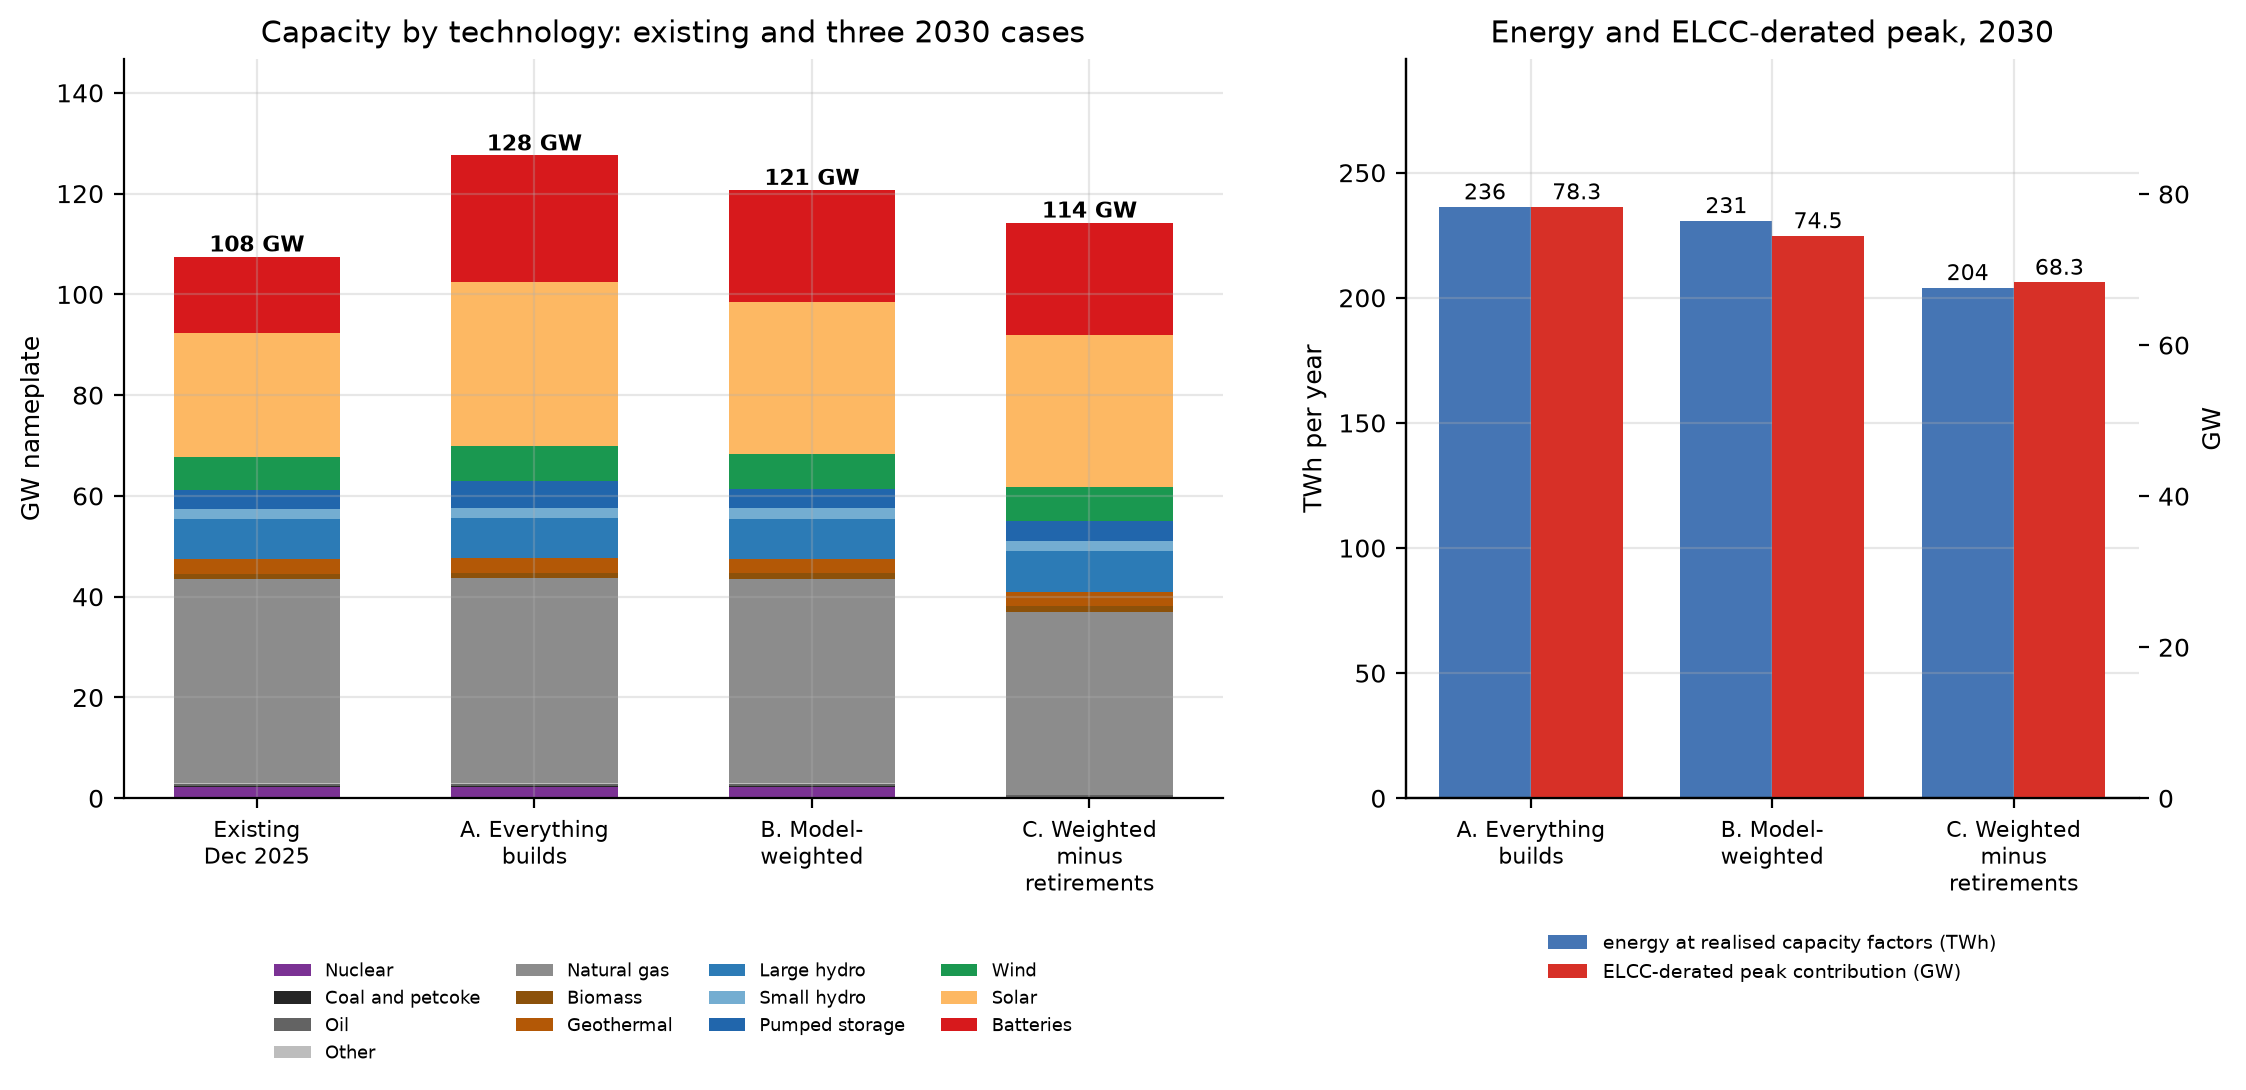

In [23]:
show("fig3_05_cases_2030")

**Reading.** If everything on the July 2026 planned list builds, California's nameplate capacity reaches 128 GW in 2030, 236 TWh a year at realised capacity factors and 78 GW of ELCC-derated peak contribution. Weighting by the realization model removes a third of the planned additions (13.2 of 20.1 GW survive: 71 percent of batteries and solar, 78 percent of wind, 31 percent of gas, 13 percent of the two pumped-storage projects, whose approvals have not been initiated), giving 121 GW, 231 TWh and 74 GW. Subtracting 6.5 GW of scheduled retirements, of which Diablo Canyon is 2.3 GW, leaves 114 GW, 204 TWh and 68 GW; with Diablo Canyon continuing, 117 GW, 222 TWh and 71 GW. The supply side therefore adds about 10 to 13 GW of nameplate and 6 to 8 GW of peak contribution by 2030 net of retirements, against the 4 GW of managed net peak growth in the adopted forecast and the 20.7 GW of data center requests located in California from chapter 2. That comparison is the object of the next chapter.